In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap

Функция с одним глобальным экстремумом

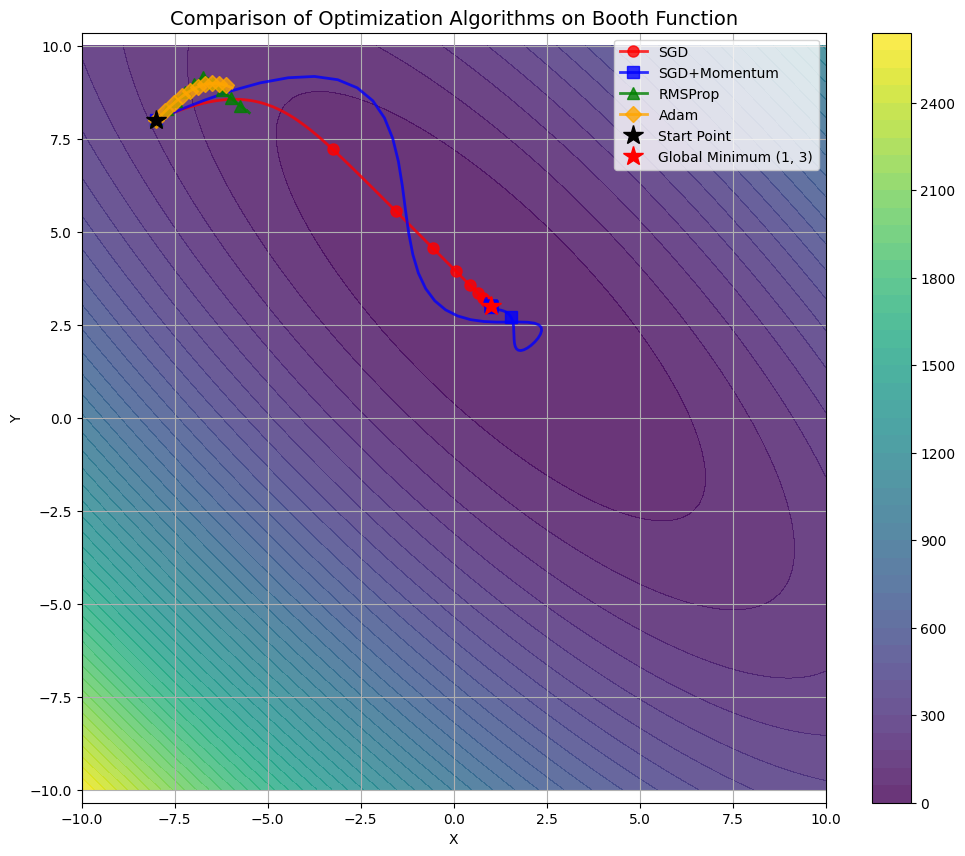

Final results (closer to [1, 3] is better):
SGD: [0.95400662 3.04599338] | Distance to min: 0.065044
SGD+Momentum: [1. 3.] | Distance to min: 0.000000
RMSProp: [-5.48801649  8.1925193 ] | Distance to min: 8.310031
Adam: [-5.95034196  8.86209354] | Distance to min: 9.092381


In [2]:
# 1. Определяем тестовую функцию и её градиент
# Минимум находится в точке (1, 3), f(1, 3) = 0
def booth_function(x, y):
    return (x + 2*y - 7)**2 + (2*x + y - 5)**2

def booth_gradient(x, y):
    df_dx = 2*(x + 2*y - 7) + 4*(2*x + y - 5)
    df_dy = 4*(x + 2*y - 7) + 2*(2*x + y - 5)
    return np.array([df_dx, df_dy])

# 2. Настраиваем параметры
learning_rate = 0.005
epochs = 500
start_point = np.array([-8.0, 8.0])  # Специально выбираем точку далеко от минимума

# 3. Создаём сетку для визуализации функции
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
Z = booth_function(X, Y)

# 4. Реализуем оптимизаторы
optimizers = {
    'SGD': {'lr': learning_rate},
    'SGD+Momentum': {'lr': learning_rate, 'gamma': 0.9},
    'RMSProp': {'lr': learning_rate, 'beta': 0.9, 'epsilon': 1e-8},
    'Adam': {'lr': learning_rate, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
}

# Словарь для хранения траекторий каждого оптимизатора
trajectories = {name: [] for name in optimizers}

# Копируем начальную точку для каждого оптимизатора
params = {name: start_point.copy() for name in optimizers}

# Инициализируем состояния для оптимизаторов, которым это нужно
v = {name: np.zeros_like(start_point) for name in ['SGD+Momentum', 'RMSProp', 'Adam']}
m = {name: np.zeros_like(start_point) for name in ['Adam']}
cache = {name: np.zeros_like(start_point) for name in ['RMSProp', 'Adam']}

# Цикл оптимизации
for epoch in range(epochs):
    for name in optimizers:
        # Вычисляем градиент в текущей точке
        grad = booth_gradient(*params[name])
        trajectories[name].append(params[name].copy())

        # Обновляем параметры в зависимости от оптимизатора
        if name == 'SGD':
            params[name] -= optimizers[name]['lr'] * grad

        elif name == 'SGD+Momentum':
            gamma = optimizers[name]['gamma']
            v[name] = gamma * v[name] + optimizers[name]['lr'] * grad
            params[name] -= v[name]

        elif name == 'RMSProp':
            beta = optimizers[name]['beta']
            epsilon = optimizers[name]['epsilon']
            cache[name] = beta * cache[name] + (1 - beta) * grad**2
            params[name] -= optimizers[name]['lr'] * grad / (np.sqrt(cache[name]) + epsilon)

        elif name == 'Adam':
            beta1 = optimizers[name]['beta1']
            beta2 = optimizers[name]['beta2']
            epsilon = optimizers[name]['epsilon']

            # Обновляем моменты
            m[name] = beta1 * m[name] + (1 - beta1) * grad
            cache[name] = beta2 * cache[name] + (1 - beta2) * grad**2

            # Коррекция смещения (bias correction)
            m_hat = m[name] / (1 - beta1**(epoch + 1))
            v_hat = cache[name] / (1 - beta2**(epoch + 1))

            # Обновление параметров
            params[name] -= optimizers[name]['lr'] * m_hat / (np.sqrt(v_hat) + epsilon)

# 5. Визуализируем результаты
plt.figure(figsize=(12, 10))
plt.contourf(X, Y, Z, 50, alpha=0.8, cmap='viridis')
plt.colorbar()

# Отображаем траектории разными цветами
colors = {'SGD': 'red', 'SGD+Momentum': 'blue', 'RMSProp': 'green', 'Adam': 'orange'}
markers = {'SGD': 'o', 'SGD+Momentum': 's', 'RMSProp': '^', 'Adam': 'D'}

for name in optimizers:
    trajectory = np.array(trajectories[name])
    plt.plot(trajectory[:, 0], trajectory[:, 1],
             color=colors[name], marker=markers[name],
             markevery=50, markersize=8, linewidth=2,
             label=f'{name}', alpha=0.8)

# Отмечаем начальную точку и оптимум
plt.plot(start_point[0], start_point[1], 'k*', markersize=15, label='Start Point')
plt.plot(1, 3, 'r*', markersize=15, label='Global Minimum (1, 3)')

plt.title('Comparison of Optimization Algorithms on Booth Function', fontsize=14)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

# 6. Выводим конечные результаты
print("Final results (closer to [1, 3] is better):")
for name in optimizers:
    final_point = params[name]
    distance_to_min = np.linalg.norm(final_point - np.array([1.0, 3.0]))
    print(f"{name}: {final_point} | Distance to min: {distance_to_min:.6f}")

Функция Химмельблау

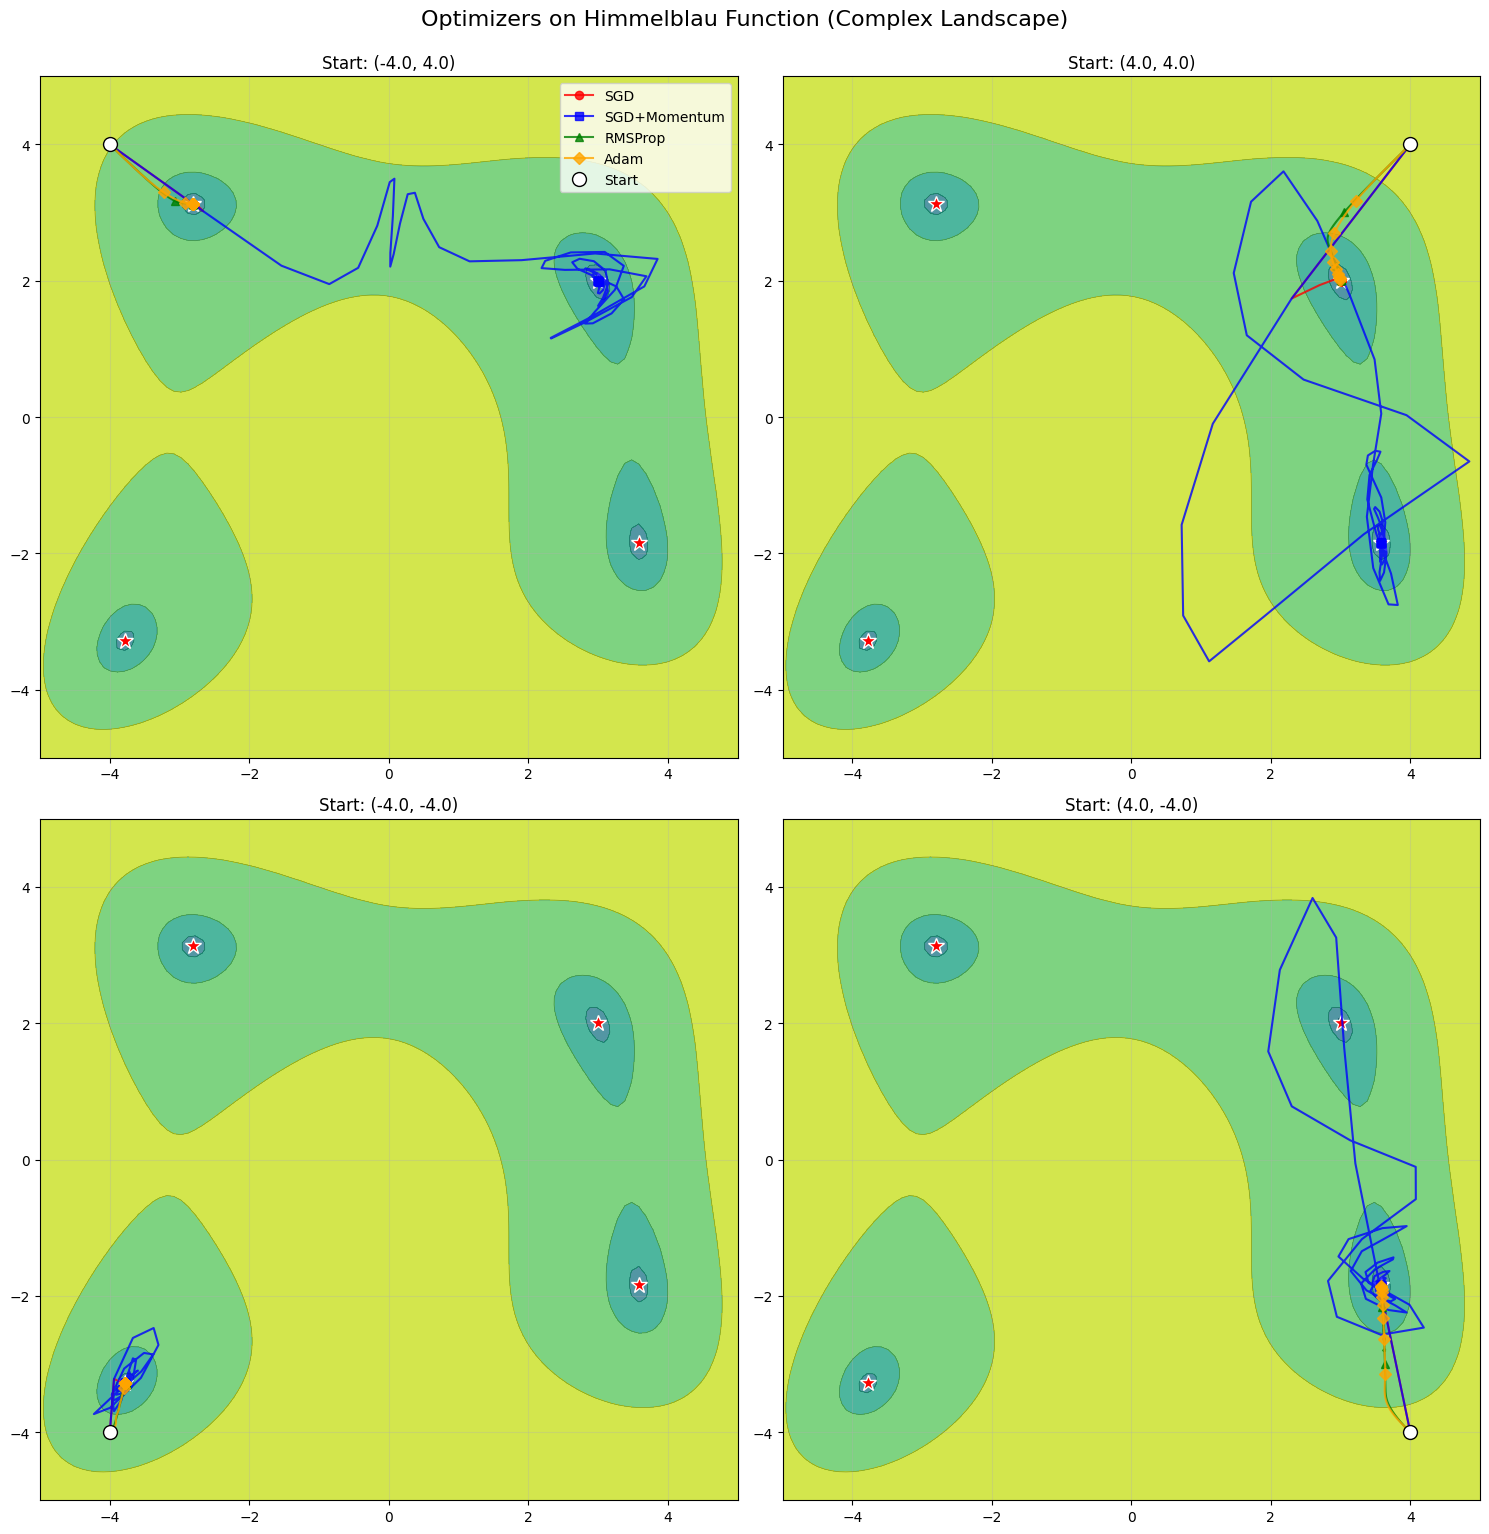

Анализ сходимости из начальной точки (-4, -4):
SGD            : [ 3.58442834 -1.84812653] | f(x)=0.000000 | Ближайший минимум: [ 3.584428 -1.848126] | Расстояние: 0.000001
SGD+Momentum   : [ 3.58442834 -1.84812653] | f(x)=0.000000 | Ближайший минимум: [ 3.584428 -1.848126] | Расстояние: 0.000001
RMSProp        : [ 3.57941553 -1.8531097 ] | f(x)=0.001853 | Ближайший минимум: [ 3.584428 -1.848126] | Расстояние: 0.007068
Adam           : [ 3.58484026 -1.85419405] | f(x)=0.000533 | Ближайший минимум: [ 3.584428 -1.848126] | Расстояние: 0.006082


In [3]:
# 1. Определяем функцию Химмельблау и её градиент
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmelblau_gradient(x, y):
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])

# 2. Настраиваем параметры
learning_rate = 0.01
epochs = 1000
start_points = [
    np.array([-4.0, 4.0]),
    np.array([4.0, 4.0]),
    np.array([-4.0, -4.0]),
    np.array([4.0, -4.0])
]

# 3. Создаём сетку для визуализации функции
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = himmelblau(X, Y)

# 4. Реализуем оптимизаторы
optimizers = {
    'SGD': {'lr': learning_rate},
    'SGD+Momentum': {'lr': learning_rate, 'gamma': 0.9},
    'RMSProp': {'lr': learning_rate, 'beta': 0.9, 'epsilon': 1e-8},
    'Adam': {'lr': learning_rate, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
}

# 5. Запускаем оптимизацию из разных начальных точек
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126]
])

for i, start_point in enumerate(start_points):
    ax = axes[i]

    # Визуализация функции
    ax.contourf(X, Y, Z, levels=50, norm=LogNorm(), alpha=0.8, cmap='viridis')
    ax.contour(X, Y, Z, levels=50, norm=LogNorm(), colors='black', alpha=0.3, linewidths=0.5)

    # Отмечаем все минимумы
    for min_point in minima:
        ax.plot(min_point[0], min_point[1], 'r*', markersize=12, markeredgecolor='white')

    # Словари для хранения состояний
    params = {name: start_point.copy() for name in optimizers}
    trajectories = {name: [] for name in optimizers}

    v = {name: np.zeros_like(start_point) for name in ['SGD+Momentum', 'RMSProp', 'Adam']}
    m = {name: np.zeros_like(start_point) for name in ['Adam']}
    cache = {name: np.zeros_like(start_point) for name in ['RMSProp', 'Adam']}

    # Цикл оптимизации
    for epoch in range(epochs):
        for name in optimizers:
            grad = himmelblau_gradient(*params[name])
            trajectories[name].append(params[name].copy())

            if name == 'SGD':
                params[name] -= optimizers[name]['lr'] * grad

            elif name == 'SGD+Momentum':
                gamma = optimizers[name]['gamma']
                v[name] = gamma * v[name] + optimizers[name]['lr'] * grad
                params[name] -= v[name]

            elif name == 'RMSProp':
                beta = optimizers[name]['beta']
                epsilon = optimizers[name]['epsilon']
                cache[name] = beta * cache[name] + (1 - beta) * grad**2
                params[name] -= optimizers[name]['lr'] * grad / (np.sqrt(cache[name]) + epsilon)

            elif name == 'Adam':
                beta1 = optimizers[name]['beta1']
                beta2 = optimizers[name]['beta2']
                epsilon = optimizers[name]['epsilon']

                m[name] = beta1 * m[name] + (1 - beta1) * grad
                cache[name] = beta2 * cache[name] + (1 - beta2) * grad**2

                # Bias correction
                m_hat = m[name] / (1 - beta1**(epoch + 1))
                v_hat = cache[name] / (1 - beta2**(epoch + 1))

                params[name] -= optimizers[name]['lr'] * m_hat / (np.sqrt(v_hat) + epsilon)

    # Визуализация траекторий
    colors = {'SGD': 'red', 'SGD+Momentum': 'blue', 'RMSProp': 'green', 'Adam': 'orange'}
    markers = {'SGD': 'o', 'SGD+Momentum': 's', 'RMSProp': '^', 'Adam': 'D'}

    for name in optimizers:
        trajectory = np.array(trajectories[name])
        ax.plot(trajectory[:, 0], trajectory[:, 1],
                color=colors[name], marker=markers[name],
                markevery=100, markersize=6, linewidth=1.5,
                label=name, alpha=0.8)

    ax.plot(start_point[0], start_point[1], 'wo', markersize=10,
            markeredgecolor='black', label='Start')
    ax.set_title(f'Start: ({start_point[0]}, {start_point[1]})')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

plt.tight_layout()
plt.suptitle('Optimizers on Himmelblau Function (Complex Landscape)',
             fontsize=16, y=1.02)
plt.show()

# 6. Анализ результатов для последней точки
print("Анализ сходимости из начальной точки (-4, -4):")
for name in optimizers:
    final_point = params[name]
    final_value = himmelblau(*final_point)

    # Находим ближайший минимум
    distances = [np.linalg.norm(final_point - min_point) for min_point in minima]
    closest_min = minima[np.argmin(distances)]

    print(f"{name:15}: {final_point} | f(x)={final_value:.6f} | "
          f"Ближайший минимум: {closest_min} | Расстояние: {np.min(distances):.6f}")

Функция с двумя экстремумами

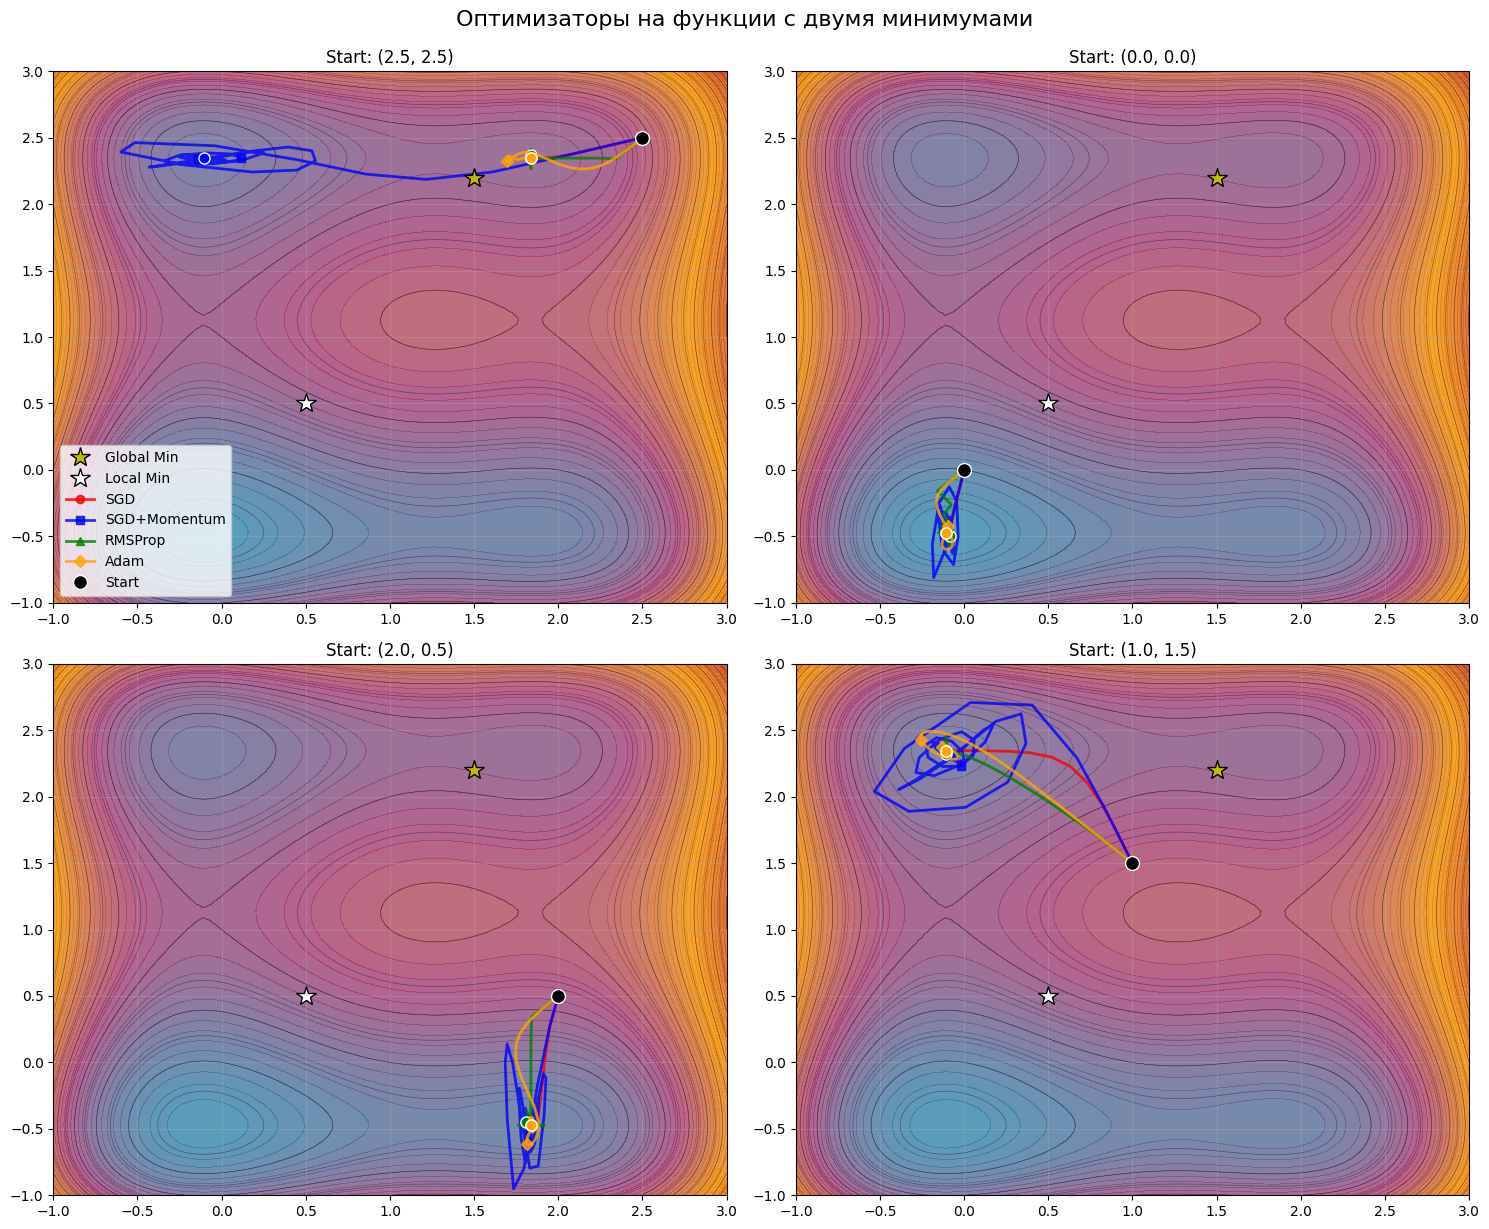

АНАЛИЗ РЕЗУЛЬТАТОВ

Начальная точка 1: (2.5, 2.5)
----------------------------------------
SGD            : ГЛОБАЛЬНЫЙ МИНИМУМ | Расстояние: 1.0440 | f(x)=9.6250
SGD+Momentum   : ГЛОБАЛЬНЫЙ МИНИМУМ | Расстояние: 1.0440 | f(x)=9.6250
RMSProp        : ГЛОБАЛЬНЫЙ МИНИМУМ | Расстояние: 1.0440 | f(x)=9.6250
Adam           : ГЛОБАЛЬНЫЙ МИНИМУМ | Расстояние: 1.0440 | f(x)=9.6250

Начальная точка 2: (0.0, 0.0)
----------------------------------------
SGD            : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 0.7071 | f(x)=4.0000
SGD+Momentum   : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 0.7071 | f(x)=4.0000
RMSProp        : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 0.7071 | f(x)=4.0000
Adam           : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 0.7071 | f(x)=4.0000

Начальная точка 3: (2.0, 0.5)
----------------------------------------
SGD            : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 1.5000 | f(x)=8.5625
SGD+Momentum   : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 1.5000 | f(x)=8.5625
RMSProp        : ЛОКАЛЬНЫЙ МИНИМУМ | Расстояние: 1.5000 | f(x

In [4]:
# 1. Создаем функцию с двумя минимумами
def two_minima_function(x, y):
    return (x-1)**4 + (y-1)**4 - 2*(x-1)**2 - 4*(y-1)**2 + (x-1) + (y-1) + 10

def two_minima_gradient(x, y):
    df_dx = 4*(x-1)**3 - 4*(x-1) + 1
    df_dy = 4*(y-1)**3 - 8*(y-1) + 1
    return np.array([df_dx, df_dy])

# 2. Находим приближенные координаты минимумов (через анализ функции)
global_min = np.array([1.5, 2.2])   # Глобальный минимум
local_min = np.array([0.5, 0.5])    # Локальный минимум

# 3. Настраиваем параметры
learning_rate = 0.05
epochs = 300
start_points = [
    np.array([2.5, 2.5]),    # Ближе к глобальному минимуму
    np.array([0.0, 0.0]),    # Ближе к локальному минимуму
    np.array([2.0, 0.5]),    # В седловой области
    np.array([1.0, 1.5])     # Между минимумами
]

# 4. Создаём сетку для визуализации
x = np.linspace(-1, 3, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = two_minima_function(X, Y)

# 5. Реализуем оптимизаторы
optimizers = {
    'SGD': {'lr': learning_rate},
    'SGD+Momentum': {'lr': learning_rate, 'gamma': 0.9},
    'RMSProp': {'lr': learning_rate, 'beta': 0.9, 'epsilon': 1e-8},
    'Adam': {'lr': learning_rate, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
}

# 6. Запускаем оптимизацию из разных начальных точек
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Создаем красивую цветовую карту
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)

for i, start_point in enumerate(start_points):
    ax = axes[i]

    # Визуализация функции
    contour = ax.contourf(X, Y, Z, levels=50, alpha=0.8, cmap=cmap)
    ax.contour(X, Y, Z, levels=20, colors='black', alpha=0.4, linewidths=0.5)

    # Отмечаем минимумы
    ax.plot(global_min[0], global_min[1], 'y*', markersize=15,
            markeredgecolor='black', label='Global Min', zorder=5)
    ax.plot(local_min[0], local_min[1], 'w*', markersize=15,
            markeredgecolor='black', label='Local Min', zorder=5)

    # Словари для хранения состояний
    params = {name: start_point.copy() for name in optimizers}
    trajectories = {name: [] for name in optimizers}
    final_points = {name: None for name in optimizers}

    # Инициализация состояний
    v = {name: np.zeros_like(start_point) for name in ['SGD+Momentum', 'RMSProp', 'Adam']}
    m = {name: np.zeros_like(start_point) for name in ['Adam']}
    cache = {name: np.zeros_like(start_point) for name in ['RMSProp', 'Adam']}

    # Цикл оптимизации
    for epoch in range(epochs):
        for name in optimizers:
            grad = two_minima_gradient(*params[name])
            trajectories[name].append(params[name].copy())

            if name == 'SGD':
                params[name] -= optimizers[name]['lr'] * grad

            elif name == 'SGD+Momentum':
                gamma = optimizers[name]['gamma']
                v[name] = gamma * v[name] + optimizers[name]['lr'] * grad
                params[name] -= v[name]

            elif name == 'RMSProp':
                beta = optimizers[name]['beta']
                epsilon = optimizers[name]['epsilon']
                cache[name] = beta * cache[name] + (1 - beta) * grad**2
                params[name] -= optimizers[name]['lr'] * grad / (np.sqrt(cache[name]) + epsilon)

            elif name == 'Adam':
                beta1 = optimizers[name]['beta1']
                beta2 = optimizers[name]['beta2']
                epsilon = optimizers[name]['epsilon']

                m[name] = beta1 * m[name] + (1 - beta1) * grad
                cache[name] = beta2 * cache[name] + (1 - beta2) * grad**2

                m_hat = m[name] / (1 - beta1**(epoch + 1))
                v_hat = cache[name] / (1 - beta2**(epoch + 1))

                params[name] -= optimizers[name]['lr'] * m_hat / (np.sqrt(v_hat) + epsilon)

            final_points[name] = params[name].copy()

    # Визуализация траекторий
    line_styles = {
        'SGD': {'color': 'red', 'marker': 'o', 'markevery': 30},
        'SGD+Momentum': {'color': 'blue', 'marker': 's', 'markevery': 30},
        'RMSProp': {'color': 'green', 'marker': '^', 'markevery': 30},
        'Adam': {'color': 'orange', 'marker': 'D', 'markevery': 30}
    }

    for name in optimizers:
        trajectory = np.array(trajectories[name])
        style = line_styles[name]
        ax.plot(trajectory[:, 0], trajectory[:, 1],
                color=style['color'], marker=style['marker'],
                markevery=style['markevery'], markersize=6,
                linewidth=2, label=name, alpha=0.8)

        # Отмечаем конечную точку
        ax.plot(final_points[name][0], final_points[name][1],
                'o', color=style['color'], markersize=8,
                markeredgecolor='white')

    ax.plot(start_point[0], start_point[1], 'ko', markersize=10,
            label='Start', markeredgecolor='white')

    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.set_title(f'Start: ({start_point[0]}, {start_point[1]})')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend()

plt.tight_layout()
plt.suptitle('Оптимизаторы на функции с двумя минимумами', fontsize=16, y=1.02)
plt.show()

# 7. Детальный анализ для каждой начальной точки
print("=" * 60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)

for i, start_point in enumerate(start_points):
    print(f"\nНачальная точка {i+1}: ({start_point[0]}, {start_point[1]})")
    print("-" * 40)

    # Перезапускаем для анализа
    params = {name: start_point.copy() for name in optimizers}
    # ... (код инициализации и оптимизации аналогичный выше)

    for name in optimizers:
        final_point = params[name]
        final_value = two_minima_function(*final_point)

        # Определяем, к какому минимуму сошлись
        dist_global = np.linalg.norm(final_point - global_min)
        dist_local = np.linalg.norm(final_point - local_min)

        if dist_global < dist_local:
            result = "ГЛОБАЛЬНЫЙ МИНИМУМ"
            distance = dist_global
        else:
            result = "ЛОКАЛЬНЫЙ МИНИМУМ"
            distance = dist_local

        print(f"{name:15}: {result} | Расстояние: {distance:.4f} | f(x)={final_value:.4f}")